In [1]:
from src.agent.graph import create_agent_graph
from IPython.display import Image, display

c:\university_chatbot\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
USER_AGENT environment variable not set, consider setting it to identify your requests.


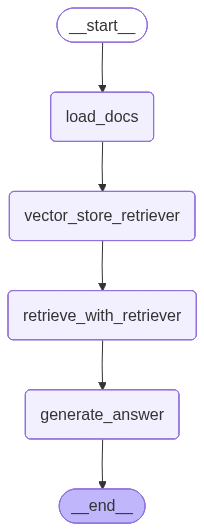

In [2]:
agent_graph = create_agent_graph()

display(Image(agent_graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

from typing_extensions import TypedDict, Annotated, Any, List
from langchain_core.documents import Document

class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

    query: str
    queries: List[str]
    path_to_docs: str

    chunk_size: int
    chunk_overlap: int

    embed_model: str
    main_model: str
    llm: Any

    top_k_docs: int
    top_k_queries: int

    raw_docs: List[Document]
    split_docs: List[Document]
    retrieved_docs: str

    final_answer: str

init_state: State = {
    "messages": [],

    "query": "Điều kiện để được xét công nhận tốt nghiệp chuương trình Đại Học là gì?",
    "queries": [],
    "path_to_docs": "data/raw_documents",

    "chunk_size": 500,
    "chunk_overlap": 50,

    "embed_model": "hf.co/CompendiumLabs/bge-m3-gguf",
    "main_model": "xiaomi/mimo-v2-pro",

    "top_k_docs": 5,
    "top_k_queries": 5,

    "raw_docs": [],
    "split_docs": [],
    "retrieved_docs": "",

    "final_answer": "",
}

graph = create_agent_graph()
final_state = graph.invoke(init_state)

print(f"Final Answer: {final_state['final_answer']}")

Final Answer: answer='Để được xét công nhận tốt nghiệp chương trình Đại học, sinh viên cần đáp ứng đầy đủ các điều kiện sau:\n\n1. **Hoàn thành chương trình đào tạo:** Đã hoàn thành đầy đủ các học phần theo yêu cầu của Chương trình Đào tạo (CTĐT) trong thời gian quy định, bao gồm cả các học phần thuộc chương trình môn học Giáo dục thể chất và Giáo dục quốc phòng-an ninh.\n\n2. **Đạt chuẩn ngoại ngữ đầu ra:** Sinh viên phải đáp ứng yêu cầu về chuẩn ngoại ngữ theo quy định.\n\n3. **Điểm trung bình tích lũy (CPA):** Điểm trung bình tích lũy toàn khóa (tính theo các học phần đăng ký tốt nghiệp) phải đạt từ 2,0 trở lên.\n\n4. **Tư cách pháp lý và kỷ luật:** Tại thời điểm xét tốt nghiệp, sinh viên không bị truy cứu trách nhiệm hình sự và không đang trong thời gian bị kỷ luật ở mức đình chỉ học tập.\n\n5. **Đăng ký xét tốt nghiệp:** Sinh viên phải đăng ký xét tốt nghiệp theo các đợt và mốc thời gian quy định trong Khung kế hoạch năm học (xét tốt nghiệp 03 đợt trong năm: cuối mỗi học kỳ chính 

In [4]:
final_state["queries"]

[]

In [5]:
final_state["retriever"]

VectorStoreRetriever(tags=['Chroma', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x0000018E0E5CAF90>, search_kwargs={'k': 5})